#### Experimento de raios catódicos para determinação de $e/m_{e}$

In [2]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [3]:
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # or 'sans-serif' for a modern look
    "font.serif": ["Computer Modern Roman"],  # default LaTeX font
    "axes.labelsize": 16,    # LaTeX font size
    "font.size": 15,
    "legend.fontsize": 15,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

In [4]:
unc_I = 0.01
unc_U = 1

#parâmetros numéricos
mu0 = 4*np.pi*10**-7
R_b = 0.20 #(m)
N_voltas = 154
r1 = 0.02 #(m)
r2 = 0.03
r3 = 0.04
r4 = 0.05

U = [100,120,140,160,180,200,220,240,250,280,300]

###################################

k = lambda r:  (r**2 / 2) * 64/125 * (mu0*N_voltas/R_b)**2 
U_func = lambda r, I: k(r)*I**2

##### Para $r = 0.02$ m

In [5]:
I1 = np.array([2.22, 2.49, 2.69, 2.96, 3.09, 3.33, 3.50, 3.62, 3.77, 3.97, 4.11])
I2 = np.array([2.43, 2.59, 2.77, 3.04, 3.27, 3.45, 3.65, 3.83, 3.91, 4.1, 4.25])

I_r1 = ((I1 + I2)*0.5).round(2)

x_r1 = U_func(I_r1, r1)
y_r1 = U

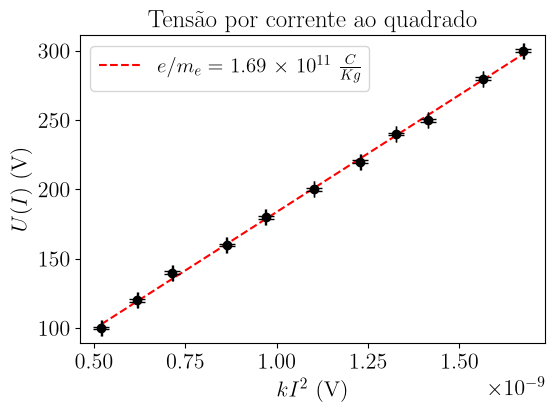

In [6]:
lin_regression = Polynomial.fit(x=x_r1, y=y_r1, deg=1)
b, a = (lin_regression.convert()).coef

x_plot = np.linspace(x_r1.min(), x_r1.max(), 500)
y_plot = lin_regression(x_plot)

plt.figure(figsize=(6,4))
plt.plot(x_plot, y_plot, label= r"$e/m_e =$"+ f" {a*10**-11:.2f}" + r" $\times$ " + r"$10^{11}$" + r" $\frac{C}{Kg}$", color="red", linestyle="dashed")
plt.errorbar(x_r1, y_r1, yerr=unc_U, xerr=k(r1)*unc_I, color="black", capsize=6, fmt="o")
plt.ylabel(r"$U(I)$ (V)")
plt.xlabel(r"$kI^{2}$ (V)")
plt.title("Tensão por corrente ao quadrado")
plt.legend()
plt.show()